In [37]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:


pytrend = TrendReq()

topics = [
    'AI',
    'Elon Musk',
    'Valorant',
    # 'iphone',

]

pytrend.build_payload(
    topics, 
    timeframe= 'today 3-m'
)

df = pytrend.interest_over_time() # returns normalize popularity score(0-100)
df

,AI,Elon Musk,Valorant,isPartial
date,,,,
2026-06-26,81,2,2,False
2026-06-27,79,2,3,False
2026-06-28,78,2,3,False
2026-06-29,83,2,2,False
2026-06-30,86,2,2,False
...,...,...,...,...
2026-09-22,71,1,3,False
2026-09-23,69,1,3,False
2026-09-24,66,1,3,False


In [7]:
anchor = ['youtube']
pytrend.build_payload(
        anchor,
        timeframe = 'today 3-m'
    )

anchor_df = pytrend.interest_over_time()
anchor_df

,youtube,isPartial
date,,
2026-06-26,86,False
2026-06-27,84,False
2026-06-28,84,False
2026-06-29,84,False
2026-06-30,88,False
...,...,...
2026-09-22,56,False
2026-09-23,52,False
2026-09-24,55,False


In [19]:
# norm_df = {}
# for topic in df:
#     norm_df[topic] = df[topic] / anchor_df['youtube']

norm_df = df.div(anchor_df['youtube'], axis=0)

In [23]:
norm_df

,AI,Elon Musk,Valorant,isPartial
date,,,,
2026-06-26,0.941860,0.023256,0.023256,0.000000
2026-06-27,0.940476,0.023810,0.035714,0.000000
2026-06-28,0.928571,0.023810,0.035714,0.000000
2026-06-29,0.988095,0.023810,0.023810,0.000000
2026-06-30,0.977273,0.022727,0.022727,0.000000
...,...,...,...,...
2026-09-22,1.267857,0.017857,0.053571,0.000000
2026-09-23,1.326923,0.019231,0.057692,0.000000
2026-09-24,1.200000,0.018182,0.054545,0.000000


In [ ]:
# interests = ['ai', 'elon musk', 'mutal funds']

# anchor_coupled_interests = []

# for i in interests:
#     anchor_coupled_interests.append([i, 'youtube'])


#could be shortend by doing follows

In [33]:
topics = ['ai', 'elon musk', 'porn']
all_topics = {}
for topic in topics:
    pytrend.build_payload(
            [topic, 'google'],
            timeframe= 'today 3-m'
        )
    
    temp = pytrend.interest_over_time()

    all_topics[topic] = temp[topic] / temp['google']



In [34]:
attention_df = pd.DataFrame(all_topics)

In [35]:
attention_df

,ai,elon musk,porn
date,,,
2026-06-26,0.620253,0.012658,0.632911
2026-06-27,0.648649,0.013514,0.716216
2026-06-28,0.610390,0.012987,0.740260
2026-06-29,0.568182,0.011364,0.522727
2026-06-30,0.634146,0.012195,0.597561
...,...,...,...
2026-09-22,0.518072,0.012048,0.638554
2026-09-23,0.545455,0.012987,0.623377
2026-09-24,0.476744,0.011628,0.604651


In [45]:
pytrend.build_payload(
        ['google'],
        timeframe= 'today 12-m'
    )

goog = pytrend.interest_over_time()

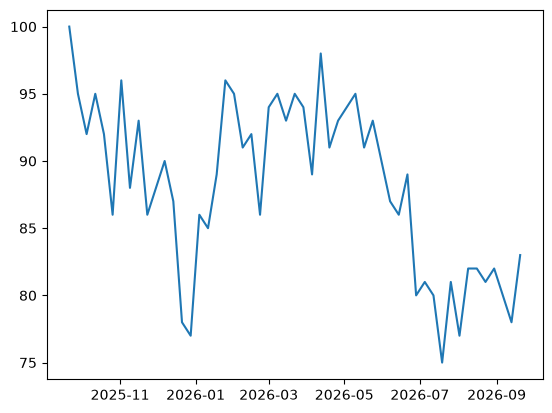

In [46]:
plt.plot(goog['google'])

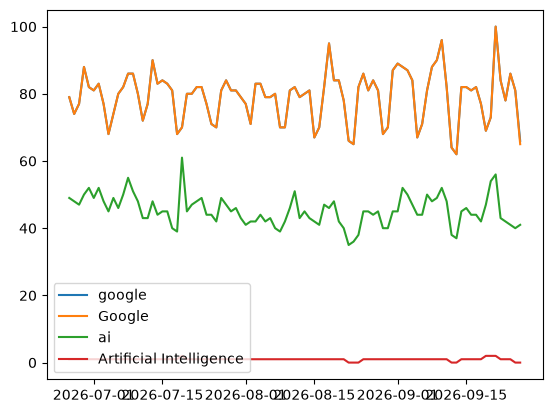

In [ ]:
#THIS confirms that trends req is case insensitive, but ai and artificial intelligence resolve to diff stuff
pytrend.build_payload(
        ['google', 'Google', 'ai', 'Artificial Intelligence'],
        timeframe= 'today 3-m'
    )

sim_testing = pytrend.interest_over_time()

for col in sim_testing.columns[:-1]:
    plt.plot(sim_testing.index, sim_testing[col], label = col)

plt.legend()

In [59]:
df.columns

Index(['AI', 'Elon Musk', 'Valorant', 'isPartial'], dtype='str')

In [75]:
import plotly.io as pio
import plotly.express as px
pio.renderers.default = 'browser'

fig = px.line(
    df,
    x=df.index,
    y="AI"
)

fig.show()

In [76]:
attention_df

,ai,elon musk,porn
date,,,
2026-06-26,0.620253,0.012658,0.632911
2026-06-27,0.648649,0.013514,0.716216
2026-06-28,0.610390,0.012987,0.740260
2026-06-29,0.568182,0.011364,0.522727
2026-06-30,0.634146,0.012195,0.597561
...,...,...,...
2026-09-22,0.518072,0.012048,0.638554
2026-09-23,0.545455,0.012987,0.623377
2026-09-24,0.476744,0.011628,0.604651


In [80]:
attention_df['ai_diff'] = attention_df['ai'].diff()

In [88]:
attention_df['ai_growth'] = attention_df['ai'].pct_change()

In [103]:
attention_df['ai_ma7'] = attention_df['ai'].rolling(7).mean()

In [93]:
attention_df['ai_acceleration'] = attention_df['ai'].pct_change().diff()

In [98]:
attention_df['ai_spike_score'] = attention_df['ai'] / attention_df['ai'].rolling(7).mean()

In [99]:
attention_df

,ai,elon musk,porn,ai_diff,ai_ma7,ai_growth,ai_acceleration,ai_ra7,ai_spike_score
date,,,,,,,,,
2026-06-26,0.620253,0.012658,0.632911,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-27,0.648649,0.013514,0.716216,0.028395,NaN,0.045780,NaN,NaN,NaN
2026-06-28,0.610390,0.012987,0.740260,-0.038259,NaN,-0.058983,-0.104763,NaN,NaN
2026-06-29,0.568182,0.011364,0.522727,-0.042208,NaN,-0.069149,-0.010166,NaN,NaN
2026-06-30,0.634146,0.012195,0.597561,0.065965,NaN,0.116098,0.185246,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-09-22,0.518072,0.012048,0.638554,-0.041928,0.587102,-0.074871,0.168092,0.587102,0.882423
2026-09-23,0.545455,0.012987,0.623377,0.027382,0.587423,0.052854,0.127725,0.587423,0.928555
2026-09-24,0.476744,0.011628,0.604651,-0.068710,0.578874,-0.125969,-0.178823,0.578874,0.823572


In [112]:
ai_scores_df = attention_df.drop(columns= ['porn', 'elon musk', 'ai_ra7'])

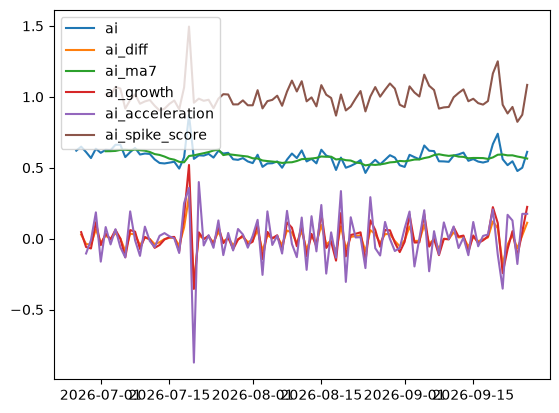

In [113]:
for score in ai_scores_df:
    plt.plot(ai_scores_df.index, ai_scores_df[score], label = score)
plt.legend()

## right now did it for ai only, later make it general

In [124]:
attention_df['ai'].iloc[-1].item()

0.6119402985074627

In [125]:
#this is the shitty seperated version
ai_scores = {
        'attention' : attention_df['ai'].iloc[-1].item(),
        'growth' : attention_df['ai_growth'].iloc[-1].item(),
        'acceleration' : attention_df['ai_acceleration'].iloc[-1].item(),
        'spike' : attention_df['ai_spike_score'].iloc[-1].item()
    }

In [126]:
ai_scores

{'attention': 0.6119402985074627,
 'growth': 0.22388059701492535,
 'acceleration': 0.17510010921004726,
 'spike': 1.083919534624787}

In [134]:
ai_scores_df.columns.tolist()

['ai', 'ai_diff', 'ai_ma7', 'ai_growth', 'ai_acceleration', 'ai_spike_score']

In [139]:
##### Better way --- GHAE Score
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
columns = ai_scores_df.columns.tolist()
ai_scores_df[columns] = scaler.fit_transform(ai_scores_df[columns])


In [140]:
ai_scores_df

,ai,ai_diff,ai_ma7,ai_growth,ai_acceleration,ai_spike_score
date,,,,,,
2026-06-26,0.384395,NaN,NaN,NaN,NaN,NaN
2026-06-27,0.453989,0.555881,NaN,0.458037,NaN,NaN
2026-06-28,0.360220,0.446040,NaN,0.338160,0.604269,NaN
2026-06-29,0.256774,0.439533,NaN,0.326527,0.678587,NaN
2026-06-30,0.418446,0.617792,NaN,0.538499,0.832107,NaN
...,...,...,...,...,...,...
2026-09-22,0.133960,0.439994,0.631257,0.319980,0.818631,0.087644
2026-09-23,0.201071,0.554211,0.634127,0.466131,0.786917,0.156346
2026-09-24,0.032669,0.395859,0.557611,0.261510,0.546086,0.000000


In [141]:
ai_scores_df["ghae_score"] = (
    0.4 * ai_scores_df["ai"] +
    0.3 * ai_scores_df["ai_growth"] +
    0.2 * ai_scores_df["ai_acceleration"] +
    0.1 * ai_scores_df["ai_spike_score"]
)

In [142]:
ai_scores_df

,ai,ai_diff,ai_ma7,ai_growth,ai_acceleration,ai_spike_score,ghae_score
date,,,,,,,
2026-06-26,0.384395,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-27,0.453989,0.555881,NaN,0.458037,NaN,NaN,NaN
2026-06-28,0.360220,0.446040,NaN,0.338160,0.604269,NaN,NaN
2026-06-29,0.256774,0.439533,NaN,0.326527,0.678587,NaN,NaN
2026-06-30,0.418446,0.617792,NaN,0.538499,0.832107,NaN,NaN
...,...,...,...,...,...,...,...
2026-09-22,0.133960,0.439994,0.631257,0.319980,0.818631,0.087644,0.322068
2026-09-23,0.201071,0.554211,0.634127,0.466131,0.786917,0.156346,0.393286
2026-09-24,0.032669,0.395859,0.557611,0.261510,0.546086,0.000000,0.200738
